In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

c:\Users\19671\anaconda3\envs\sun\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_all.npz')
doppler_vel_all = data['doppler_vel_all']
sigma_vel_all = data['sigma_vel_all']

进行谱线展宽的修正，去掉热展宽和仪器展宽  
以及需要注意sigma用的是正态分布的，差了个根号二  
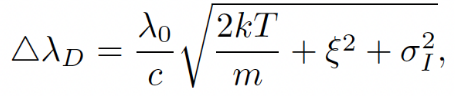  
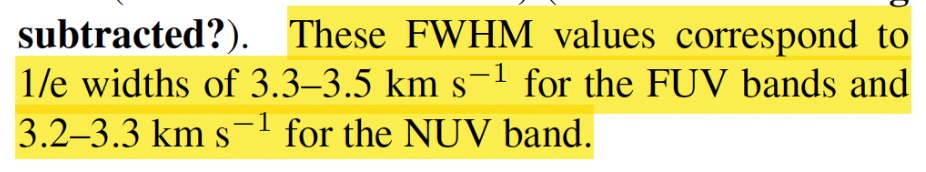  
122-200是FUV 300-400是NUV

In [26]:
#这里用的是SiIV 1402.77这条谱线
#FWHM/1402.77*C=3.25KM/S
#FWHM=sqrt(ln(2))*sigma
sigma_I=3.25/np.sqrt(np.log(2))
#之后算热致展宽,这个已经是平方项了
sigma_thermal=2*1.38*10**(-23)*10**(4.9)/(1.67*10**(-27))/1e6
threshold=np.sqrt(sigma_I**2+sigma_thermal)
sigma_vel_nonth=np.zeros((12,110))
for i in range(12):
    for j in range(110):
        if sigma_vel_all[i,j]*np.sqrt(2)>threshold:
            sigma_vel_nonth[i,j]=np.sqrt(sigma_vel_all[i,j]**2*2-threshold**2)
        else:
            sigma_vel_nonth[i,j]=0
np.savez(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_nonth.npz',
         doppler_vel_all=doppler_vel_all,sigma_vel_nonth=sigma_vel_nonth)
#这里的sigma_vel_nonth就是非热展宽

In [14]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')

In [15]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%d T%H:%M:%S')
    time_sequence.append(time_str)

In [ ]:
#生成多普勒速度（单高斯）和非热展宽的图
for cnt in range(12):
	i=797+2*cnt
	fig,down_ax=plt.subplots(figsize=(5.5,5))
	fig_data=all_sji_image[i][0][330:,:]
	down_ax.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
	extent=[0,422*0.166,0,330*0.166])
	down_ax.set_xlabel('X [arcsec]')
	down_ax.set_ylabel('Y [arcsec]')
	down_ax.set_aspect('auto')  # 或 'box' 而不是 'equal'
	right_ax = down_ax.twinx()
	right_ax.set_ylim(110, 220)
	right_ax.set_ylabel('pixel along the slit')
	#创建第二根x轴
	up_ax=down_ax.twiny()
	#转化单位到角秒
	y_vals=np.linspace(0,330*0.166,110)
	up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
	up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
	up_ax.set_xlim(-210,190)
	wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
	x=wave_x[70:110]

	up_ax.set_xlabel('Velocity [km/s]')
	up_ax.set_title(time_sequence[i])
	up_ax.legend()
	up_ax.minorticks_on()
	up_ax.axvline(0,color='blue',linestyle='--')
	fig.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\fig_with_vel\\'+str(i)+'.png',dpi=300)
	plt.close(fig)


In [29]:
def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2, c):
    return (a1 * np.exp(-(x - x1)**2 / (sigma1**2)) +
            a2 * np.exp(-(x - x2)**2 / (sigma2**2)) + c)

def fit_double_gaussian(x1_initial,x2_initial,x,rsm,start_x,end_x,path):
    velocity=np.zeros((end_x-start_x,4))
    #如果没有则创建目标文件夹
    if not os.path.exists(path):
        os.makedirs(path)
    
    #进行双高斯拟合
    for i in range(start_x,end_x):
        y=rsm[4].data[4,65+i*3:68+i*3,:].mean(axis=0)[70:110]
        #剔除掉一些特别大的点
        mask=y>4*np.mean(y)
        if np.any(mask):
            good_idx=np.where(~mask)[0]
            y_interp=np.interp(np.arange(len(y)),good_idx,y[good_idx])
            y[mask]=y_interp[mask]
        #设置初始拟合参数
        a1_initial=max(y)-min(y)
        sigma1_initial=0.1
        a2_initial=a1_initial
        sigma2_initial=sigma1_initial
        c_initial=min(y)
        initial_guess=[a1_initial,x1_initial,sigma1_initial,
        a2_initial,x2_initial,sigma2_initial,c_initial]

        #进行双高斯拟合
        popt, pcov = curve_fit(double_gaussian, x, y, p0=initial_guess, maxfev=5000)
        a1_fit, x1_fit, sigma1_fit, a2_fit, x2_fit, sigma2_fit, c_fit = popt
        velocity[i-start_x,0]=(x1_fit-1402.77)/1402.77*299792.458
        velocity[i-start_x,1]=sigma1_fit/1402.77*299792.458
        velocity[i-start_x,2]=(x2_fit-1402.77)/1402.77*299792.458
        velocity[i-start_x,3]=sigma2_fit/1402.77*299792.458

        #绘图看双高斯拟合的结果
        x_fit = np.linspace(min(x), max(x), 1000)
        y_fit = double_gaussian(x_fit, *popt)
        plt.figure(figsize=(10, 6))
        plt.scatter(x, y, label="data", color="red")  # 画原始数据点
        plt.plot(x_fit, y_fit, label="Double Gaussian Fitting", color="blue")  # 画拟合曲线
        plt.axvline(x=1402.77,color='black',linestyle='--')
        plt.title("Double Gaussian Fitting")
        plt.xlabel("x"),plt.ylabel("y"),plt.legend(),plt.grid()
        plt.savefig(path+str(i)+'.png'),plt.close()
    return velocity

In [37]:
start_x=168
end_x=182
x1_initial=1402.77
x2_initial=1402.4
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
x=wave_x[70:110]
rsm=fits.open(file_list[399])
path=r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_figure\double_799\\'
vel=fit_double_gaussian(x1_initial,x2_initial,x,rsm,
                        start_x,end_x,path)


In [36]:
class VelocityData:
    def __init__(self, time, start_x, end_x, velocity_matrix):
        self.time = time
        self.start_x = start_x
        self.end_x = end_x
        self.velocity_matrix = velocity_matrix
all_data=[]

In [38]:
all_data.append(VelocityData(f"time_{i+1}",start_x,end_x,vel))

In [ ]:
class VelocityData:
    def __init__(self, time, start_x, end_x, velocity_matrix):
        self.time = time
        self.start_x = start_x
        self.end_x = end_x
        self.velocity_matrix = velocity_matrix

# 存储所有数据
all_data = []
for i in range(12):
    start_x = ...  # 你的start_x
    end_x = ...    # 你的end_x
    velocity_matrix = np.zeros((4, end_x - start_x))
    
    all_data.append(VelocityData(f"time_{i+1}", start_x, end_x, velocity_matrix))

# 保存数据
import pickle
with open("velocity_data.pkl", "wb") as f:
    pickle.dump(all_data, f)
